# E1 — Experimental reconstruction and crossing statistics

This notebook reconstructs the deterministic and engineered-noise measurements directly from the oscilloscope CSV files.  It computes charge, current, energy, the deterministic and noisy crossing times, the trajectory-bootstrap interval, and the late-time covariance fractions reported in the manuscript.

## Guiding question

How are these quantities obtained from the measured channels while keeping current calibration, dynamical damping, timing conventions, and stochastic interpretation physically distinct?

## What is calculated

1. Read the two Tektronix channels from the measured CSV files.
2. Reconstruct $q=CV_C$, $I=-V_R/R_{\rm ext}$, and $E=CV_C^2/2+LI^2/2$.
3. Keep $R_{\rm ext}$, $R_{\rm comp}$, and the fitted $R_{\rm dyn}$ conceptually separate.
4. Determine the deterministic and ensemble crossing times.
5. Verify $\overline E=E_\mu+E_\Sigma$ with the finite-$N$ covariance convention used in the analysis.
6. Recompute the 50,000-resample trajectory-bootstrap interval and the 40--100 ms covariance fractions.
7. Record input-file hashes and compare the reconstructed numerical values with the stored reference summary.

### Timing and noise conventions

The deterministic records use the common $7.2\,\mathrm{ms}$ trigger-to-release offset.  The engineered-noise records remain on the oscilloscope trigger-time coordinate.  The injected AWGN is not assigned an effective thermal temperature.


In [1]:
from pathlib import Path
import json, csv, re, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Locate the project root from the notebook directory or its parents.
def locate_root(start=Path.cwd()):
    candidates = [start, start.parent, start.parent.parent]
    for p in candidates:
        if (p / "experimental_data" / "raw").exists():
            return p.resolve()
    raise FileNotFoundError("Could not locate the project directory containing experimental_data/raw/." )

ROOT = locate_root()
RAW = ROOT / "experimental_data" / "raw"
REF = ROOT / "experimental_data" / "reference"
OUT_DATA = ROOT / "notebook_outputs" / "data"
OUT_FIG = ROOT / "notebook_outputs" / "figures"
OUT_DATA.mkdir(parents=True, exist_ok=True)
OUT_FIG.mkdir(parents=True, exist_ok=True)

# ---------------- Plot-style switch ----------------
# Safe default: executes everywhere with Matplotlib only.
# Local options:
#   PLOT_STYLE = "science-no-latex"  -> requires `pip install scienceplots`
#   PLOT_STYLE = "science-latex"     -> additionally requires a local LaTeX install
PLOT_STYLE = "matplotlib"

def apply_plot_style(style=PLOT_STYLE):
    plt.style.use("default")
    if style.startswith("science"):
        try:
            import scienceplots  # noqa: F401
            plt.style.use(["science", "no-latex"] if style == "science-no-latex" else ["science"])
        except ImportError:
            warnings.warn("scienceplots is not installed; falling back to Matplotlib.")
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 9.0,
        "axes.labelsize": 9.0,
        "axes.titlesize": 9.5,
        "legend.fontsize": 7.5,
        "xtick.labelsize": 8.0,
        "ytick.labelsize": 8.0,
        "axes.linewidth": 0.7,
        "lines.linewidth": 1.3,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.04,
    })

apply_plot_style()

# Measured/component values used in the manuscript.
L_H = 44.4e-3
C_F = 454e-6
R_EXT_OHM = 22.2
R_COMP_OHM = 27.9
DETERMINISTIC_RELEASE_S = 7.2e-3

print("Data files located successfully.")
print(f"Plot style: {PLOT_STYLE}")


Data files located successfully.
Plot style: matplotlib


In [2]:
def sha256(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def read_scope_csv(path):
    """Read the two Tektronix channel blocks stored side-by-side in one CSV."""
    path = Path(path)
    rows = list(csv.reader(path.open(newline="", encoding="utf-8", errors="ignore")))
    channels = {}
    for block_start in (0, 6):
        metadata = {}
        for row in rows[:20]:
            if len(row) > block_start + 1 and row[block_start].strip():
                metadata[row[block_start].strip()] = row[block_start + 1].strip()
        n = int(round(float(metadata["Record Length"])))
        dt = float(metadata["Sample Interval"])
        trigger = float(metadata["Trigger Point"])
        values = []
        for row in rows:
            if len(row) > block_start + 4:
                try:
                    values.append(float(row[block_start + 4]))
                except ValueError:
                    pass
        values = np.asarray(values, dtype=float)
        assert len(values) == n, (path.name, block_start, len(values), n)
        time_s = (np.arange(n, dtype=float) - trigger) * dt
        source = metadata.get("Source", f"CH{len(channels)+1}")
        channels[source] = {
            "time_s": time_s,
            "values": values,
            "metadata": metadata,
            "dt_s": dt,
        }
    assert set(channels) == {"CH1", "CH2"}
    assert np.allclose(channels["CH1"]["time_s"], channels["CH2"]["time_s"])
    return channels


def reconstruct_scope(path, release_shift_s=None):
    channels = read_scope_csv(path)
    t_trigger = channels["CH1"]["time_s"]
    vc = channels["CH1"]["values"]
    vr = channels["CH2"]["values"]
    current = -vr / R_EXT_OHM
    charge = C_F * vc
    energy = 0.5 * C_F * vc**2 + 0.5 * L_H * current**2
    frame = pd.DataFrame({
        "time_after_trigger_s": t_trigger,
        "Vc_V": vc,
        "Vr_V": vr,
        "q_C": charge,
        "I_A": current,
        "E_J": energy,
    })
    if release_shift_s is not None:
        frame.insert(1, "time_after_release_s", t_trigger - release_shift_s)
    return frame, channels


def first_crossing(t1, e1, t2, e2, start_s=0.0):
    """First sign change of e1-e2, with linear interpolation."""
    t1 = np.asarray(t1); e1 = np.asarray(e1); t2 = np.asarray(t2); e2 = np.asarray(e2)
    mask = (t1 >= start_s) & (t1 <= t2[-1])
    tx = t1[mask]
    d = e1[mask] - np.interp(tx, t2, e2)
    idx = np.where(np.diff(np.signbit(d)))[0]
    if len(idx) == 0:
        return np.nan, np.nan
    i = int(idx[0])
    tc = tx[i] - d[i] * (tx[i+1] - tx[i]) / (d[i+1] - d[i])
    ec = float(np.interp(tc, tx, e1[mask]))
    return float(tc), ec


## 1. Deterministic traces

The deterministic dataset contains one fast and one slow trace.  Their sampling intervals differ, so one energy curve is interpolated onto the time grid of the other when locating the crossing.


In [3]:
DET_DIR = RAW / "deterministic"
det_files = {"fast": DET_DIR / "arapido_02(1).csv", "slow": DET_DIR / "alento_02(1).csv"}

det = {}
meta_rows = []
for mode, path in det_files.items():
    frame, channels = reconstruct_scope(path, release_shift_s=DETERMINISTIC_RELEASE_S)
    det[mode] = frame
    meta_rows.append({
        "mode": mode,
        "file": path.name,
        "sha256": sha256(path),
        "n": len(frame),
        "dt_us": 1e6 * channels["CH1"]["dt_s"],
        "nearest_release_us": 1e6 * frame.loc[frame["time_after_release_s"].abs().idxmin(), "time_after_release_s"],
    })

metadata_table = pd.DataFrame(meta_rows)
display(metadata_table)

for mode, frame in det.items():
    frame.to_csv(OUT_DATA / f"deterministic_{mode}_reconstructed.csv", index=False)


,mode,file,sha256,n,dt_us,nearest_release_us
0,fast,arapido_02(1).csv,d50a2734323da7fea117e1c391a0efd80d669991609664...,2500,39.999999,-0.000182
1,slow,alento_02(1).csv,7b420f0eabbaa7869304a235faa53029a78e40accf54d6...,2500,399.999990,-0.040182


### Measured deterministic crossing

Charge, current, and energy are reconstructed from the measured channels before any dynamical model is applied.  The first crossing after release is therefore obtained directly from the two measured energy curves.


In [4]:
fast = det["fast"]; slow = det["slow"]
tx_det, ex_det = first_crossing(
    fast["time_after_release_s"], fast["E_J"],
    slow["time_after_release_s"], slow["E_J"], start_s=0.0
)

idx_f0 = fast["time_after_release_s"].abs().idxmin()
idx_s0 = slow["time_after_release_s"].abs().idxmin()
summary_det = pd.DataFrame({
    "quantity": ["fast E near release", "slow E near release", "measured crossing time", "crossing energy"],
    "value": [1e6*fast.loc[idx_f0,"E_J"], 1e6*slow.loc[idx_s0,"E_J"], 1e3*tx_det, 1e6*ex_det],
    "unit": ["uJ", "uJ", "ms", "uJ"],
})
display(summary_det)

assert fast.loc[idx_f0,"E_J"] > slow.loc[idx_s0,"E_J"]
assert np.isfinite(tx_det) and tx_det > 0


,quantity,value,unit
0,fast E near release,1992.739135,uJ
1,slow E near release,219.948408,uJ
2,measured crossing time,1.898250,ms
3,crossing energy,165.862321,uJ


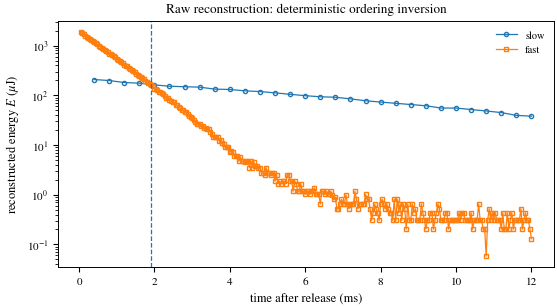

In [5]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
for mode, marker in [("slow","o"),("fast","s")]:
    d = det[mode]
    m = (d["time_after_release_s"] >= 0) & (d["time_after_release_s"] <= 0.012)
    ax.plot(1e3*d.loc[m,"time_after_release_s"], 1e6*d.loc[m,"E_J"], marker=marker,
            ms=3, mfc="none", lw=0.9, label=mode)
ax.axvline(1e3*tx_det, ls="--", lw=0.9)
ax.set_yscale("log")
ax.set_xlabel("time after release (ms)")
ax.set_ylabel(r"reconstructed energy $E$ ($\mu$J)")
ax.legend(frameon=False)
ax.set_title("Raw reconstruction: deterministic ordering inversion")
plt.show()


## 2. Noisy archive: energy must be formed run by run

Because energy is quadratic, in general
$$
E(\overline X)\neq \overline{E(X)}.
$$
The notebook therefore reconstructs $E$ for every trajectory first and only then forms the ensemble average. The difference is the covariance contribution.


In [6]:
NOISE_DIR = RAW / "engineered_noise"
noise_files = sorted(NOISE_DIR.glob("*.csv"), key=lambda p: (0 if "rapido" in p.stem else 1, int(re.search(r"\d+", p.stem).group())))
fast_files = [p for p in noise_files if "rapido" in p.stem]
slow_files = [p for p in noise_files if "lento" in p.stem]
assert len(fast_files) == len(slow_files) == 10

runs = {"fast": [], "slow": []}
run_time = None
for mode, files in [("fast", fast_files), ("slow", slow_files)]:
    for run_no, path in enumerate(files, start=1):
        frame, _ = reconstruct_scope(path, release_shift_s=None)
        t = frame["time_after_trigger_s"].to_numpy()
        if run_time is None:
            run_time = t
        assert np.allclose(t, run_time)
        frame["run"] = run_no
        runs[mode].append(frame)

print(f"Loaded {len(runs['fast'])} fast + {len(runs['slow'])} slow noisy trajectories; {len(run_time)} samples each.")


Loaded 10 fast + 10 slow noisy trajectories; 2500 samples each.


In [7]:
def ensemble_statistics(frames):
    vc = np.vstack([d["Vc_V"].to_numpy() for d in frames])
    cur = np.vstack([d["I_A"].to_numpy() for d in frames])
    eng = np.vstack([d["E_J"].to_numpy() for d in frames])
    mu_v = vc.mean(axis=0)
    mu_i = cur.mean(axis=0)
    E_mu = 0.5*C_F*mu_v**2 + 0.5*L_H*mu_i**2
    # ddof=0 implements the finite-N covariance convention used in the moment identity.
    E_sigma = 0.5*C_F*vc.var(axis=0, ddof=0) + 0.5*L_H*cur.var(axis=0, ddof=0)
    return {
        "energies": eng,
        "mean_E": eng.mean(axis=0),
        "sd_E": eng.std(axis=0, ddof=1),
        "E_mu": E_mu,
        "E_sigma": E_sigma,
    }

ens = {mode: ensemble_statistics(frames) for mode, frames in runs.items()}
closure = {mode: float(np.max(np.abs(v["mean_E"] - v["E_mu"] - v["E_sigma"]))) for mode,v in ens.items()}
print("Maximum moment-closure residuals [J]:", closure)
assert max(closure.values()) < 2e-19


Maximum moment-closure residuals [J]: {'fast': 1.3658406274475593e-19, 'slow': 5.505714157152952e-20}


### Noisy ensemble crossing and bootstrap

The bootstrap resamples complete trajectories, not individual time samples. This preserves the temporal structure within each run. The random seed and replicate count are fixed so the interval is exactly reproducible.


In [8]:
tx_noise, ex_noise = first_crossing(run_time, ens["fast"]["mean_E"], run_time, ens["slow"]["mean_E"], start_s=0.0)

BOOTSTRAP_SEED = 20260908
BOOTSTRAP_REPLICATES = 50_000
rng = np.random.default_rng(BOOTSTRAP_SEED)
# Each replicate draws 10 fast trajectories and 10 slow trajectories.
draws = rng.integers(0, 10, size=(BOOTSTRAP_REPLICATES, 20))

# Only non-negative times through 8 ms are needed to locate the first crossing.
m = (run_time >= 0) & (run_time <= 0.008)
tc = run_time[m]
Ef = ens["fast"]["energies"][:,m]
Es = ens["slow"]["energies"][:,m]

boot_cross = np.empty(BOOTSTRAP_REPLICATES)
batch = 1000
for lo in range(0, BOOTSTRAP_REPLICATES, batch):
    hi = min(lo+batch, BOOTSTRAP_REPLICATES)
    d = draws[lo:hi]
    mf = Ef[d[:,:10]].mean(axis=1)
    ms = Es[d[:,10:]].mean(axis=1)
    diff = mf - ms
    changes = np.diff(np.signbit(diff), axis=1)
    assert changes.any(axis=1).all()
    j = changes.argmax(axis=1)
    rows = np.arange(hi-lo)
    d0 = diff[rows,j]; d1 = diff[rows,j+1]
    t0 = tc[j]; t1 = tc[j+1]
    boot_cross[lo:hi] = t0 - d0*(t1-t0)/(d1-d0)

ci68 = np.percentile(1e3*boot_cross, [16,84])
ci95 = np.percentile(1e3*boot_cross, [2.5,97.5])
print(f"Noisy ensemble crossing: {1e3*tx_noise:.9f} ms")
print(f"68% trajectory-bootstrap interval: {ci68}")
print(f"95% trajectory-bootstrap interval: {ci95}")


Noisy ensemble crossing: 1.551108631 ms
68% trajectory-bootstrap interval: [1.49743492 1.59246408]
95% trajectory-bootstrap interval: [1.46810118 1.62066483]


### Moment decomposition at late times

The covariance fraction plotted in the manuscript is
$$
E_\Sigma/\overline E.
$$
The quoted late-time number is the ratio of the average covariance contribution to the average total energy over 40–100 ms.


In [9]:
late = (run_time >= 0.040) & (run_time <= 0.100)
late_fraction = {
    mode: float(v["E_sigma"][late].mean()/v["mean_E"][late].mean())
    for mode,v in ens.items()
}
print("Late covariance fractions (40–100 ms):", late_fraction)

ensemble_table = pd.DataFrame({
    "time_s": run_time,
    "mean_E_fast_J": ens["fast"]["mean_E"],
    "sd_E_fast_J": ens["fast"]["sd_E"],
    "mean_E_slow_J": ens["slow"]["mean_E"],
    "sd_E_slow_J": ens["slow"]["sd_E"],
    "E_mu_fast_J": ens["fast"]["E_mu"],
    "E_sigma_fast_J": ens["fast"]["E_sigma"],
    "E_mu_slow_J": ens["slow"]["E_mu"],
    "E_sigma_slow_J": ens["slow"]["E_sigma"],
})
ensemble_table.to_csv(OUT_DATA/"noisy_ensemble_summary.csv", index=False)
pd.DataFrame({"crossing_ms":1e3*boot_cross}).to_csv(OUT_DATA/"noisy_crossing_bootstrap.csv", index=False)


Late covariance fractions (40–100 ms): {'fast': 0.9017713033056958, 'slow': 0.8756769646625443}


## 3. Check against reported values

The reconstructed crossing times, bootstrap interval, and late-time covariance fractions are compared numerically with the stored reference summary.


In [10]:
reference_values = json.loads((REF/"reported_reconstruction_values.json").read_text())
checks = pd.DataFrame([
    ["deterministic crossing (ms)", 1e3*tx_det, reference_values["noiseless_crossing_ms"], 2e-4],
    ["noisy crossing (ms)", 1e3*tx_noise, reference_values["noisy"]["crossing_ms"], 2e-4],
    ["bootstrap 95% lower (ms)", ci95[0], reference_values["noisy"]["bootstrap_95_ms"][0], 2e-4],
    ["bootstrap 95% upper (ms)", ci95[1], reference_values["noisy"]["bootstrap_95_ms"][1], 2e-4],
    ["fast late covariance fraction", late_fraction["fast"], reference_values["noisy"]["late_fast_covariance_fraction"], 2e-6],
    ["slow late covariance fraction", late_fraction["slow"], reference_values["noisy"]["late_slow_covariance_fraction"], 2e-6],
], columns=["quantity","reproduced","reference","tolerance"])
checks["abs_difference"] = (checks["reproduced"]-checks["reference"]).abs()
checks["PASS"] = checks["abs_difference"] <= checks["tolerance"]
display(checks)
assert checks["PASS"].all()

summary = {
    "constants": {"L_H":L_H,"C_F":C_F,"R_ext_ohm":R_EXT_OHM,"R_component_ohm":R_COMP_OHM,"deterministic_release_ms":1e3*DETERMINISTIC_RELEASE_S},
    "deterministic_crossing_ms": float(1e3*tx_det),
    "deterministic_crossing_energy_uJ": float(1e6*ex_det),
    "noisy_crossing_ms": float(1e3*tx_noise),
    "bootstrap_seed": BOOTSTRAP_SEED,
    "bootstrap_replicates": BOOTSTRAP_REPLICATES,
    "bootstrap_95_ms": ci95.tolist(),
    "late_covariance_fraction": late_fraction,
    "moment_closure_max_J": closure,
    "deterministic_input_hashes": {mode:sha256(path) for mode,path in det_files.items()},
    "noise_file_hashes": {p.name:sha256(p) for p in noise_files},
}
(OUT_DATA/"E1_reconstruction_summary.json").write_text(json.dumps(summary, indent=2))
print("E1 numerical check: PASS")


,quantity,reproduced,reference,tolerance,abs_difference,PASS
0,deterministic crossing (ms),1.898250,1.898250,0.000200,0.0,True
1,noisy crossing (ms),1.551109,1.551109,0.000200,0.0,True
2,bootstrap 95% lower (ms),1.468101,1.468101,0.000200,0.0,True
3,bootstrap 95% upper (ms),1.620665,1.620665,0.000200,0.0,True
4,fast late covariance fraction,0.901771,0.901771,0.000002,0.0,True
5,slow late covariance fraction,0.875677,0.875677,0.000002,0.0,True


E1 numerical check: PASS


## Optional: first-order calibration uncertainty propagation

The manuscript's central crossings are reconstructed directly from the measured records, while component and calibration uncertainties are reported separately. If independent uncertainties are assigned to $C,L,R_{\rm ext},V_C,V_R$, the first-order propagated energy uncertainty is
$$
\sigma_E^2\simeq\sum_j\left(\frac{\partial E}{\partial x_j}\sigma_{x_j}\right)^2.
$$
The helper below implements this formula. Channel-voltage uncertainties must come from the relevant instrument/calibration model; the notebook does not invent them.


In [11]:
def energy_uncertainty(Vc,Vr,sVc,sVr,C,sC,L,sL,R,sR):
    I=-Vr/R
    dC=.5*Vc**2
    dL=.5*I**2
    dR=-L*Vr**2/R**3
    dVc=C*Vc
    dVr=L*Vr/R**2
    var=(dC*sC)**2+(dL*sL)**2+(dR*sR)**2+(dVc*sVc)**2+(dVr*sVr)**2
    return np.sqrt(var)

print('energy_uncertainty helper defined; supply instrument-specific sVc and sVr when needed.')


energy_uncertainty helper defined; supply instrument-specific sVc and sVr when needed.


### Component-parameter contribution

The component uncertainties stated for the experiment are $\sigma_C=8\,\mu\mathrm F$, $\sigma_L=1.2\,\mathrm{mH}$, and $\sigma_{R_{\rm ext}}=0.7\,\Omega$.  The next cell evaluates their contribution to the reconstructed energy uncertainty at release.  It sets the channel-voltage terms to zero, so the result is **not** a total measurement uncertainty; oscilloscope and voltage-calibration contributions require their own calibration data.


In [12]:
SIGMA_C_F = 8e-6
SIGMA_L_H = 1.2e-3
SIGMA_R_EXT_OHM = 0.7

component_uncertainty = []
for mode, frame, idx in [("fast", fast, idx_f0), ("slow", slow, idx_s0)]:
    sigma_E = energy_uncertainty(
        Vc=frame.loc[idx,"Vc_V"], Vr=frame.loc[idx,"Vr_V"],
        sVc=0.0, sVr=0.0,
        C=C_F, sC=SIGMA_C_F,
        L=L_H, sL=SIGMA_L_H,
        R=R_EXT_OHM, sR=SIGMA_R_EXT_OHM,
    )
    component_uncertainty.append([mode, 1e6*frame.loc[idx,"E_J"], 1e6*sigma_E])

component_uncertainty = pd.DataFrame(
    component_uncertainty,
    columns=["preparation","energy_uJ","component_parameter_sigma_uJ"]
)
display(component_uncertainty)


,preparation,energy_uJ,component_parameter_sigma_uJ
0,fast,1992.739135,121.946516
1,slow,219.948408,3.790970


## Interpretation limits

The calculations above establish the reconstruction and ensemble statistics.  They do not calibrate the engineered AWGN as a thermal bath, and they do not identify the current-sense resistance with the total dynamical resistance.  All numerical checks use the measured CSV records.
